# TOI-3235b Synthetic Emission Exploration
Load the results from running retrievals on a suite of synthetic TOI-3235b emission spectra spanning a range of metallicities and cloud top pressures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
base_folder = Path("TOI3235b_synthetic_emission")

emission_results_folder = base_folder / "emission_retrieval_results"
synthetic_spectra_folder = base_folder / "synthetic_emission_spectra"

In [3]:
result_dirs = sorted([p for p in emission_results_folder.iterdir() if p.is_dir()])

print(f"Found {len(result_dirs)} result directories.")

Found 35 result directories.


In [4]:
def parse_result_dirname(dirname):
    """
    Parse directory names formatted like:
        {met}met_{logPcloud}logpcloud_{nobs}obs
        
    Returns
    -------
    met_true : float
    logp_true : float
    """
    name = Path(dirname).name

    met_str = name.split("met_")[0]
    logp_str = name.split("met_")[1].split("logpcloud")[0]

    met_true = float(met_str)
    logp_true = float(logp_str)

    return met_true, logp_true

In [5]:
rows = []

for run_dir in result_dirs:

    met_true, logp_true = parse_result_dirname(run_dir.name)
    run_name = run_dir.name

    results_pkl = run_dir / f"{run_name}_results.pkl"
    binned_spec = run_dir / f"{run_name}_binned_posterior_spectrum1.npy"
    full_spec = run_dir / f"{run_name}_full_posterior_spectrum1.npy"
    wavelengths = run_dir / f"{run_name}_wavelengths_R10000.npy"
    idx_file = run_dir / f"{run_name}_idx.npy"

    rows.append({
        "run_name": run_name,
        "run_dir": str(run_dir),
        "met_true": met_true,
        "logPcloud_true": logp_true,
        "met_round": round(met_true, 2),
        "logPcloud_round": round(logp_true, 1),
        "results_pkl": str(results_pkl),
        "binned_spectrum": str(binned_spec),
        "full_spectrum": str(full_spec),
        "wavelengths_file": str(wavelengths),
        "idx_file": str(idx_file),
        "has_results_pkl": results_pkl.exists(),
        "has_binned_spectrum": binned_spec.exists(),
        "has_full_spectrum": full_spec.exists(),
        "has_wavelengths": wavelengths.exists(),
        "has_idx": idx_file.exists(),
    })

df_runs = pd.DataFrame(rows)

df_runs = df_runs.sort_values(
    ["met_true", "logPcloud_true"]
).reset_index(drop=True)

df_runs.head()

,run_name,run_dir,met_true,logPcloud_true,met_round,logPcloud_round,results_pkl,binned_spectrum,full_spectrum,wavelengths_file,idx_file,has_results_pkl,has_binned_spectrum,has_full_spectrum,has_wavelengths,has_idx
0,-3.3499999999999996met_-5.1logpcloud_1obs,TOI3235b_synthetic_emission/emission_retrieval...,-3.35,-5.1,-3.35,-5.1,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,True,True,True,True,True
1,-3.3499999999999996met_-3.3logpcloud_1obs,TOI3235b_synthetic_emission/emission_retrieval...,-3.35,-3.3,-3.35,-3.3,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,True,True,True,True,True
2,-3.3499999999999996met_-1.4999999999999998logp...,TOI3235b_synthetic_emission/emission_retrieval...,-3.35,-1.5,-3.35,-1.5,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,True,True,True,True,True
3,-3.3499999999999996met_0.30000000000000027logp...,TOI3235b_synthetic_emission/emission_retrieval...,-3.35,0.3,-3.35,0.3,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,True,True,True,True,True
4,-3.3499999999999996met_2.1logpcloud_1obs,TOI3235b_synthetic_emission/emission_retrieval...,-3.35,2.1,-3.35,2.1,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,TOI3235b_synthetic_emission/emission_retrieval...,True,True,True,True,True


In [6]:
posterior_columns = [
    "T_high", "T_deep",
    "CO2", "CH4", "H2O", "NH3", "HCN", "CO", "SO2", "H2S", "C2H2", "C2H4",
    "Pcloud", "sigma_w1", "log_a", "gamma", "Pref"
]

species_list = [
    "CO2", "CH4", "H2O", "NH3", "HCN", "CO", "SO2", "H2S", "C2H2", "C2H4"
]

print(f"Number of posterior columns: {len(posterior_columns)}")
print(f"Number of trace species: {len(species_list)}")

Number of posterior columns: 17
Number of trace species: 10


In [7]:
try:
    from exocomp import Abund

    abund = Abund(solar="Asplund09")
    solar_abund = abund.solar_abundances

    metals_sum_solar = 0.0
    for elem, valerr in solar_abund.items():
        if elem not in ["H", "He"]:
            metals_sum_solar += 10**valerr[0]

    h_abund_solar = 10**solar_abund["H"][0]
    metallicity_solar = metals_sum_solar / h_abund_solar

    print(f"Using exocomp Asplund09 solar metallicity: {metallicity_solar:.6e}")

except Exception as e:
    print("Could not import/use exocomp. Falling back to approximate solar metallicity.")
    print("Error:", e)

    metallicity_solar = 1.0e-3
    print(f"Fallback metallicity_solar = {metallicity_solar:.6e}")

Need to install easychem!
Using exocomp Asplund09 solar metallicity: 1.041222e-03


In [8]:
species_atom_dict = {
    "H2": {"H": 2},
    "He": {"He": 1},
    "CO2": {"C": 1, "O": 2},
    "CH4": {"C": 1, "H": 4},
    "H2O": {"H": 2, "O": 1},
    "NH3": {"N": 1, "H": 3},
    "HCN": {"H": 1, "C": 1, "N": 1},
    "CO": {"C": 1, "O": 1},
    "SO2": {"S": 1, "O": 2},
    "H2S": {"H": 2, "S": 1},
    "C2H2": {"C": 2, "H": 2},
    "C2H4": {"C": 2, "H": 4},
}

In [9]:
def compute_met_coo(df, species_atom_dict, metallicity_solar=metallicity_solar):
    """
    Compute C/O and log10 metallicity relative to solar from molecular abundances.

    This follows the same convention as the existing retrieval notebooks:
        metallicity = sum(non-H2/He molecular mixing ratios) / (H2 + He)
    """

    n_samples = len(df)

    n_C = np.zeros(n_samples)
    n_O = np.zeros(n_samples)
    n_N = np.zeros(n_samples)
    n_S = np.zeros(n_samples)
    n_H = np.zeros(n_samples)
    n_He = np.zeros(n_samples)
    n_metals = np.zeros(n_samples)

    for sp, atoms_in_sp in species_atom_dict.items():

        if sp not in df.columns:
            continue

        ratio = df[sp].values

        for atom, num in atoms_in_sp.items():
            if atom == "C":
                n_C += num * ratio
            elif atom == "O":
                n_O += num * ratio
            elif atom == "N":
                n_N += num * ratio
            elif atom == "S":
                n_S += num * ratio
            elif atom == "H":
                n_H += num * ratio
            elif atom == "He":
                n_He += num * ratio

        if sp not in ["H2", "He"]:
            n_metals += ratio

    co_ratio = n_C / n_O

    total_h2he = df["H2"].values + df["He"].values
    metallicity = n_metals / total_h2he

    log_met_rel_solar = np.full_like(metallicity, np.nan, dtype=float)
    valid = np.isfinite(metallicity) & (metallicity > 0)
    log_met_rel_solar[valid] = np.log10(metallicity[valid] / metallicity_solar)

    return co_ratio, log_met_rel_solar

In [10]:
def weighted_percentile(data, weights, percentiles):
    """
    Compute weighted percentiles.
    """

    data = np.asarray(data)
    weights = np.asarray(weights)

    mask = np.isfinite(data) & np.isfinite(weights) & (weights >= 0)
    data = data[mask]
    weights = weights[mask]

    if len(data) == 0:
        return np.full(len(percentiles), np.nan)

    if np.sum(weights) <= 0:
        return np.full(len(percentiles), np.nan)

    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]

    cdf = np.cumsum(weights_sorted)
    cdf /= cdf[-1]

    return np.interp(np.asarray(percentiles) / 100.0, cdf, data_sorted)

In [11]:
def load_posterior_samples(results_pkl):
    """
    Load posterior samples from one emission retrieval results.pkl file.

    Returns
    -------
    df : pandas.DataFrame
        Posterior samples with named columns.
    logz : float
        Final dynesty log-evidence.
    """

    with open(results_pkl, "rb") as f:
        pkl_output = pickle.load(f)

    samples = pkl_output["posterior_samples"]

    if samples.shape[1] != len(posterior_columns):
        raise ValueError(
            f"Expected {len(posterior_columns)} columns, got {samples.shape[1]}"
        )

    df = pd.DataFrame(samples, columns=posterior_columns)

    metals_sum = df[species_list].sum(axis=1)
    df["H2"] = (1.0 - metals_sum) / 1.17
    df["He"] = 0.17 * df["H2"]

    df["logPcloud"] = np.log10(df["Pcloud"])
    df["logPref"] = np.log10(df["Pref"])
    df["log_sigma_w1"] = np.log10(df["sigma_w1"])

    logz = pkl_output["dynesty_results"]["logz"][-1]

    return df, logz

In [12]:
def generate_prior_metallicity_samples(
    n_prior_samples=500_000,
    seed=42,
    logX_min=-12,
    logX_max=-1,
):
    """
    Generate prior samples from the same independent log-uniform abundance priors
    and compute the induced metallicity prior.
    """

    rng = np.random.default_rng(seed)

    prior_samples = {}

    for sp in species_list:
        log_X = rng.uniform(logX_min, logX_max, n_prior_samples)
        prior_samples[sp] = 10**log_X

    prior_df = pd.DataFrame(prior_samples)

    metals_sum = prior_df[species_list].sum(axis=1)
    prior_df["H2"] = (1.0 - metals_sum) / 1.17
    prior_df["He"] = 0.17 * prior_df["H2"]

    _, prior_log_met = compute_met_coo(prior_df, species_atom_dict)

    valid = np.isfinite(prior_log_met)
    prior_log_met = prior_log_met[valid]

    return prior_log_met

In [13]:
def make_quantile_bin_edges(samples, n_bins=200, pad=1e-6):
    """
    Make adaptive bin edges using prior quantiles.
    """

    samples = np.asarray(samples)
    samples = samples[np.isfinite(samples)]

    qs = np.linspace(0.0, 1.0, n_bins + 1)
    edges = np.quantile(samples, qs)

    edges = np.unique(edges)

    edges[0] -= pad
    edges[-1] += pad

    return edges

In [14]:
def make_hist_density(samples, bin_edges):
    """
    Estimate density with a histogram.
    Zero-density bins remain zero.
    """

    samples = np.asarray(samples)
    samples = samples[np.isfinite(samples)]

    counts, _ = np.histogram(samples, bins=bin_edges)
    widths = np.diff(bin_edges)

    density = np.zeros_like(widths, dtype=float)

    good = (counts > 0) & (widths > 0)
    density[good] = counts[good] / counts.sum() / widths[good]

    return density

In [15]:
def get_density_for_samples(samples, bin_edges, density_values):
    """
    Evaluate histogram density at sample positions.
    Samples outside the prior histogram range get NaN.
    """

    samples = np.asarray(samples)

    bin_indices = np.digitize(samples, bin_edges) - 1

    inside = (
        np.isfinite(samples)
        & (bin_indices >= 0)
        & (bin_indices < len(density_values))
    )

    density_at_samples = np.full(len(samples), np.nan, dtype=float)
    density_at_samples[inside] = density_values[bin_indices[inside]]

    return density_at_samples

In [16]:
def compute_inverse_prior_weights(
    samples,
    bin_edges,
    prior_density,
    min_ess_frac_warn=0.01,
    max_weight_warn=0.05,
):
    """
    Compute normalized inverse-prior weights.
    Zero prior density or NaN density gives zero weight.
    """

    samples = np.asarray(samples)

    density_at_samples = get_density_for_samples(
        samples,
        bin_edges,
        prior_density,
    )

    valid = (
        np.isfinite(samples)
        & np.isfinite(density_at_samples)
        & (density_at_samples > 0)
    )

    raw_weights = np.zeros_like(samples, dtype=float)
    raw_weights[valid] = 1.0 / density_at_samples[valid]

    if raw_weights.sum() > 0:
        weights = raw_weights / raw_weights.sum()
    else:
        weights = raw_weights

    sum_w2 = np.sum(weights**2)
    ess = 1.0 / sum_w2 if sum_w2 > 0 else np.nan
    ess_frac = ess / len(samples) if len(samples) > 0 else np.nan
    max_weight = np.max(weights) if len(weights) > 0 else np.nan
    top10_weight_sum = np.sort(weights)[-10:].sum() if len(weights) >= 10 else np.nan

    n_excluded = np.sum(~valid)

    reliable = (
        np.isfinite(ess_frac)
        and ess_frac >= min_ess_frac_warn
        and np.isfinite(max_weight)
        and max_weight <= max_weight_warn
    )

    diagnostics = {
        "ess": ess,
        "ess_frac": ess_frac,
        "max_weight": max_weight,
        "top10_weight_sum": top10_weight_sum,
        "n_excluded": n_excluded,
        "frac_excluded": n_excluded / len(samples) if len(samples) > 0 else np.nan,
        "reweight_reliable": reliable,
    }

    return weights, ess, diagnostics

In [17]:
prior_log_met = generate_prior_metallicity_samples(
    n_prior_samples=500_000,
    seed=42,
)

print(f"Prior metallicity samples: {len(prior_log_met)}")
print(
    "Prior log10(Z/Zsun): "
    f"median={np.median(prior_log_met):.2f}, "
    f"16-84=[{np.percentile(prior_log_met, 16):.2f}, "
    f"{np.percentile(prior_log_met, 84):.2f}]"
)

n_met_prior_bins = 200

met_bin_edges = make_quantile_bin_edges(
    prior_log_met,
    n_bins=n_met_prior_bins,
)

prior_met_density = make_hist_density(
    prior_log_met,
    met_bin_edges,
)

print(f"Using adaptive prior-quantile metallicity bins: {len(met_bin_edges)-1}")
print(f"Prior bin width range: {np.diff(met_bin_edges).min():.4f} to {np.diff(met_bin_edges).max():.4f}")
print(f"Zero-density prior bins: {np.sum(prior_met_density == 0)}")

Prior metallicity samples: 500000
Prior log10(Z/Zsun): median=1.38, 16-84=[0.27, 1.94]
Using adaptive prior-quantile metallicity bins: 200
Prior bin width range: 0.0066 to 3.0531
Zero-density prior bins: 0


In [18]:
def summarize_one_retrieval(row, met_bin_edges, prior_met_density):
    """
    Load one retrieval, compute original and reweighted metallicity statistics.
    """

    df_post, logz = load_posterior_samples(row["results_pkl"])

    retrieved_co, retrieved_met = compute_met_coo(df_post, species_atom_dict)

    valid = np.isfinite(retrieved_met)
    retrieved_met = retrieved_met[valid]

    orig_p16, orig_p50, orig_p84 = np.percentile(retrieved_met, [16, 50, 84])

    weights, ess, rw_diag = compute_inverse_prior_weights(
        retrieved_met,
        met_bin_edges,
        prior_met_density,
    )

    rw_p05, rw_p16, rw_p50, rw_p84, rw_p95 = weighted_percentile(
        retrieved_met,
        weights,
        [5, 16, 50, 84, 95],
    )

    orig_width68 = orig_p84 - orig_p16
    rw_width68 = rw_p84 - rw_p16
    rw_width90 = rw_p95 - rw_p05

    met_inj = row["met_true"]

    inj_in_rw_68 = (rw_p16 <= met_inj <= rw_p84)
    inj_in_rw_90 = (rw_p05 <= met_inj <= rw_p95)

    p_super = np.sum(weights[retrieved_met > 0])
    p_sub = np.sum(weights[retrieved_met < 0])

    if met_inj > 0:
        p_correct_side = p_super
    elif met_inj < 0:
        p_correct_side = p_sub
    else:
        p_correct_side = np.nan

    summary = {
        "run_name": row["run_name"],
        "met_true": row["met_true"],
        "logPcloud_true": row["logPcloud_true"],
        "met_round": row["met_round"],
        "logPcloud_round": row["logPcloud_round"],
        "logz": logz,
        "n_samples": len(retrieved_met),

        "ess_met": ess,
        "ess_frac": rw_diag["ess_frac"],
        "max_weight": rw_diag["max_weight"],
        "top10_weight_sum": rw_diag["top10_weight_sum"],
        "n_excluded": rw_diag["n_excluded"],
        "frac_excluded": rw_diag["frac_excluded"],
        "reweight_reliable": rw_diag["reweight_reliable"],

        "orig_met_p16": orig_p16,
        "orig_met_p50": orig_p50,
        "orig_met_p84": orig_p84,
        "orig_met_width68": orig_width68,

        "rw_met_p05": rw_p05,
        "rw_met_p16": rw_p16,
        "rw_met_p50": rw_p50,
        "rw_met_p84": rw_p84,
        "rw_met_p95": rw_p95,
        "rw_met_width68": rw_width68,
        "rw_met_width90": rw_width90,

        "inj_in_rw_68": inj_in_rw_68,
        "inj_in_rw_90": inj_in_rw_90,

        "p_super": p_super,
        "p_sub": p_sub,
        "p_correct_side": p_correct_side,
    }

    return summary

In [19]:
summary_rows = []

for i, row in df_runs.iterrows():

    print(f"[{i+1:02d}/{len(df_runs)}] Processing {row['run_name']} ...")

    summary = summarize_one_retrieval(
        row,
        met_bin_edges,
        prior_met_density,
    )

    summary_rows.append(summary)

    print(
        f"  rw met = {summary['rw_met_p50']:.2f} "
        f"(+{summary['rw_met_p84']-summary['rw_met_p50']:.2f}/"
        f"-{summary['rw_met_p50']-summary['rw_met_p16']:.2f}), "
        f"W68={summary['rw_met_width68']:.2f}, "
        f"Pcorrect={summary['p_correct_side']:.2f}"
    )

df_met_summary = pd.DataFrame(summary_rows)

df_met_summary = df_met_summary.sort_values(
    ["met_true", "logPcloud_true"]
).reset_index(drop=True)

print("\nDone.")
print(f"Successfully summarized {len(df_met_summary)} retrievals.")

df_met_summary.head()

[01/35] Processing -3.3499999999999996met_-5.1logpcloud_1obs ...


/astro/planet/zko/miniconda3/envs/new/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


  rw met = -1.41 (+2.74/-1.42), W68=4.16, Pcorrect=0.68
[02/35] Processing -3.3499999999999996met_-3.3logpcloud_1obs ...


/astro/planet/zko/miniconda3/envs/new/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


  rw met = -1.63 (+2.96/-1.30), W68=4.25, Pcorrect=0.69
[03/35] Processing -3.3499999999999996met_-1.4999999999999998logpcloud_1obs ...


...

/astro/planet/zko/miniconda3/envs/new/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


  rw met = 2.36 (+0.11/-0.71), W68=0.82, Pcorrect=0.99
[35/35] Processing 2.05met_2.1logpcloud_1obs ...


/astro/planet/zko/miniconda3/envs/new/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


  rw met = 1.77 (+0.61/-1.07), W68=1.67, Pcorrect=0.95

Done.
Successfully summarized 35 retrievals.


,run_name,met_true,logPcloud_true,met_round,logPcloud_round,logz,n_samples,ess_met,ess_frac,max_weight,...,rw_met_p50,rw_met_p84,rw_met_p95,rw_met_width68,rw_met_width90,inj_in_rw_68,inj_in_rw_90,p_super,p_sub,p_correct_side
0,-3.3499999999999996met_-5.1logpcloud_1obs,-3.35,-5.1,-3.35,-5.1,-1116.045268,59406,2137.354907,0.035979,0.001214,...,-1.409671,1.327639,2.286992,4.160969,5.773360,False,True,0.321538,0.678462,0.678462
1,-3.3499999999999996met_-3.3logpcloud_1obs,-3.35,-3.3,-3.35,-3.3,-1111.448474,73725,2496.011036,0.033856,0.000934,...,-1.633907,1.322917,2.300133,4.252852,5.778817,False,True,0.308906,0.691094,0.691094
2,-3.3499999999999996met_-1.4999999999999998logp...,-3.35,-1.5,-3.35,-1.5,-1124.058171,81056,3233.714589,0.039895,0.000991,...,-0.814541,1.696092,2.393907,4.337392,6.025038,False,True,0.380878,0.619122,0.619122
3,-3.3499999999999996met_0.30000000000000027logp...,-3.35,0.3,-3.35,0.3,-1114.720757,92041,3762.995238,0.040884,0.000471,...,-2.417699,0.478701,2.131949,3.478336,5.523695,False,True,0.193408,0.806592,0.806592
4,-3.3499999999999996met_2.1logpcloud_1obs,-3.35,2.1,-3.35,2.1,-1111.095408,105958,3335.488345,0.031479,0.000784,...,-1.240789,1.291167,2.040873,4.078574,5.331932,False,False,0.342391,0.657609,0.657609


In [20]:
met_grid = np.array([-3.35, -2.45, -1.55, -0.65, 0.25, 1.15, 2.05])
logp_grid = np.array([-5.1, -3.3, -1.5, 0.3, 2.1])

In [21]:
pivot_width = df_met_summary.pivot(
    index="met_round",
    columns="logPcloud_round",
    values="rw_met_width68",
)

pivot_width = pivot_width.reindex(index=met_grid, columns=logp_grid)

pivot_pcorrect = df_met_summary.pivot(
    index="met_round",
    columns="logPcloud_round",
    values="p_correct_side",
)

pivot_pcorrect = pivot_pcorrect.reindex(index=met_grid, columns=logp_grid)

display(pivot_width)
display(pivot_pcorrect)

logPcloud_round,-5.1,-3.3,-1.5,0.3,2.1
met_round,,,,,
-3.35,4.160969,4.252852,4.337392,3.478336,4.078574
-2.45,4.318505,4.231653,4.328351,0.985003,1.059987
-1.55,4.362635,4.053910,4.056512,1.098996,0.981329
-0.65,4.305726,4.340731,4.117147,1.230762,1.534890
0.25,4.273551,4.396070,3.114194,2.677167,1.510685
1.15,4.212140,4.064394,2.871334,1.753206,1.895939
2.05,4.219555,4.097389,2.021077,0.815655,1.671625


logPcloud_round,-5.1,-3.3,-1.5,0.3,2.1
met_round,,,,,
-3.35,0.678462,0.691094,0.619122,0.806592,0.657609
-2.45,0.616515,0.643990,0.713245,0.996436,0.999105
-1.55,0.673523,0.712576,0.711038,0.997503,0.983220
-0.65,0.555380,0.652710,0.711779,0.930816,0.890201
0.25,0.327305,0.314196,0.649070,0.682230,0.295344
1.15,0.300579,0.308295,0.725282,0.887112,0.739146
2.05,0.329253,0.281313,0.903213,0.994948,0.952137


In [22]:
def get_run_row(met, logp, df=df_runs, atol_met=1e-3, atol_logp=1e-3):
    """
    Return the df_runs row matching rounded injected metallicity and logPcloud.
    """

    match = df[
        np.isclose(df["met_round"], met, atol=atol_met)
        & np.isclose(df["logPcloud_round"], logp, atol=atol_logp)
    ]

    if len(match) == 0:
        raise ValueError(f"No completed run found for met={met}, logPcloud={logp}")

    if len(match) > 1:
        print(f"Warning: found {len(match)} matches; using first.")

    return match.iloc[0]

In [23]:
def load_metallicity_for_run(met, logp):
    """
    Load raw and prior-corrected metallicity posterior for a given completed run.
    """

    row = get_run_row(met, logp)

    df_post, logz = load_posterior_samples(row["results_pkl"])

    _, retrieved_met = compute_met_coo(df_post, species_atom_dict)

    valid = np.isfinite(retrieved_met)
    retrieved_met = retrieved_met[valid]

    weights, ess, rw_diag = compute_inverse_prior_weights(
        retrieved_met,
        met_bin_edges,
        prior_met_density,
    )

    raw_p16, raw_p50, raw_p84 = np.percentile(retrieved_met, [16, 50, 84])

    rw_p05, rw_p16, rw_p50, rw_p84, rw_p95 = weighted_percentile(
        retrieved_met,
        weights,
        [5, 16, 50, 84, 95],
    )

    p_super = np.sum(weights[retrieved_met > 0])
    p_sub = np.sum(weights[retrieved_met < 0])

    out = {
        "row": row,
        "run_name": row["run_name"],
        "met_true": row["met_true"],
        "logPcloud_true": row["logPcloud_true"],
        "met_round": row["met_round"],
        "logPcloud_round": row["logPcloud_round"],
        "logz": logz,

        "retrieved_met": retrieved_met,
        "weights": weights,
        "ess": ess,
        "ess_frac": ess / len(retrieved_met),

        "raw_p16": raw_p16,
        "raw_p50": raw_p50,
        "raw_p84": raw_p84,

        "rw_p05": rw_p05,
        "rw_p16": rw_p16,
        "rw_p50": rw_p50,
        "rw_p84": rw_p84,
        "rw_p95": rw_p95,
        "rw_width68": rw_p84 - rw_p16,

        "p_super": p_super,
        "p_sub": p_sub,
    }

    return out

In [24]:
def load_spectrum_for_run(met, logp):
    """
    Load synthetic noisy spectrum, retrieved binned posterior spectrum,
    and injected noiseless model for a given representative case.

    Uses the matched run_name from df_runs to avoid float-format filename issues.
    """

    row = get_run_row(met, logp)
    run_name = row["run_name"]

    # Synthetic noisy spectrum
    synthetic_txt = synthetic_spectra_folder / f"{run_name}.txt"

    # Injected noiseless model
    injected_model_file = synthetic_spectra_folder / f"{run_name}.npy"

    # Retrieved binned posterior spectrum
    binned_spectrum_file = Path(row["binned_spectrum"])

    print("Loading:")
    print("  synthetic_txt       =", synthetic_txt)
    print("  injected_model_file =", injected_model_file)
    print("  binned_spectrum     =", binned_spectrum_file)

    wavelengths1, lw1, uw1, depths1, depths_error1 = np.loadtxt(
        synthetic_txt,
        unpack=True,
        usecols=(0, 1, 2, 3, 4),
    )

    spectrum1 = np.load(binned_spectrum_file)

    model_wl = np.load(synthetic_spectra_folder / "PRISM_wl.npy")
    model_spectrum = np.load(injected_model_file)

    out = {
        "row": row,
        "run_name": run_name,

        "wavelengths1": wavelengths1,
        "depths1": depths1,
        "depths_error1": depths_error1,

        "spectrum1": spectrum1,

        "model_wl": model_wl,
        "model_spectrum": model_spectrum,
    }

    return out

In [25]:
def plot_one_spectrum(ax, met, logp, title=None, show_ylabel=True):
    """
    Plot synthetic spectrum, retrieved spectrum, and injected model.
    """

    spec = load_spectrum_for_run(met, logp)

    wavelengths1 = spec["wavelengths1"]
    depths1 = spec["depths1"]
    depths_error1 = spec["depths_error1"]
    spectrum1 = spec["spectrum1"]
    model_wl = spec["model_wl"]
    model_spectrum = spec["model_spectrum"]

    median_spec = np.median(spectrum1, axis=0)
    std_spec = np.std(spectrum1, axis=0)

    lower = median_spec - std_spec
    upper = median_spec + std_spec

    ax.errorbar(
        wavelengths1,
        depths1,
        yerr=depths_error1,
        fmt="o",
        ms=2.5,
        lw=0.7,
        color="gray",
        ecolor="0.75",
        alpha=0.55,
        label="Synthetic spectrum",
        zorder=3,
    )

    ax.plot(
        wavelengths1,
        median_spec,
        color="tab:orange",
        lw=1.8,
        label="Retrieved spectrum",
        zorder=4,
    )

    ax.fill_between(
        wavelengths1,
        lower,
        upper,
        color="tab:orange",
        alpha=0.25,
        zorder=1,
    )

    ax.plot(
        model_wl,
        model_spectrum,
        color="black",
        ls="--",
        lw=1.2,
        label="Injected model",
        zorder=5,
    )

    ax.set_xlabel(r"Wavelength [$\mu$m]")

    if show_ylabel:
        ax.set_ylabel("Eclipse Depth [ppm]")
    else:
        ax.set_ylabel("")

    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.grid(False)

    if title is not None:
        ax.set_title(title)

    return ax

In [26]:
def plot_one_metallicity_posterior(
    ax,
    met,
    logp,
    bins=np.linspace(-4, 4, 81),
    title=None,
    show_ylabel=True,
):
    """
    Plot prior-corrected metallicity posterior.
    """

    out = load_metallicity_for_run(met, logp)

    retrieved_met = out["retrieved_met"]
    weights = out["weights"]

    ax.hist(
        retrieved_met,
        bins=bins,
        weights=weights,
        density=True,
        histtype="stepfilled",
        color="tab:orange",
        alpha=0.45,
        label="Prior-corrected posterior",
    )

    ax.hist(
        retrieved_met,
        bins=bins,
        weights=weights,
        density=True,
        histtype="step",
        color="tab:orange",
        lw=2.0,
    )

    ax.axvspan(
        out["rw_p16"],
        out["rw_p84"],
        color="tab:orange",
        alpha=0.16,
        label=r"Central 68% interval",
    )

    ax.axvline(
        out["rw_p50"],
        color="tab:orange",
        lw=1.7,
        label="Posterior median",
    )

    ax.axvline(
        out["met_true"],
        color="black",
        lw=2.0,
        label="Injected value",
    )

    ax.axvline(
        0,
        color="black",
        lw=1.3,
        ls="--",
        alpha=0.75,
        label="Solar",
    )

    ax.set_xlim(-4, 4)
    ax.set_xlabel(r"Retrieved $[\mathrm{M/H}]$")

    if show_ylabel:
        ax.set_ylabel("Probability density")
    else:
        ax.set_ylabel("")

    ax.grid(False)

    if title is not None:
        ax.set_title(title)

    W68 = out["rw_width68"]

    if out["met_true"] < 0:
        p_correct = out["p_sub"]
        pcorrect_text = rf"$P_{{\rm correct}}=P([\mathrm{{M/H}}]<0)={p_correct:.2f}$"
    else:
        p_correct = out["p_super"]
        pcorrect_text = rf"$P_{{\rm correct}}=P([\mathrm{{M/H}}]>0)={p_correct:.2f}$"

    txt = (
        rf"$W_{{68}}={W68:.2f}$ dex"
        + "\n"
        + pcorrect_text
    )

    ax.text(
        0.04,
        0.95,
        txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.9,
            edgecolor="0.85",
        ),
    )

    return ax, out

In [27]:
# Representative cases

representative_cases_3 = [
    (2.05, -5.1, "high-altitude clouds, unconstrained [M/H]"),
    (-1.55,  0.3, "medium-altitude clouds, sub-solar [M/H]"),
    ( 2.05,  2.1, "low-altitude clouds, super-solar [M/H]"),
]

## Figure 7

In [28]:
fig7_data = {}

for met, logp, subtitle in representative_cases_3:

    print(f"Loading case: [M/H]={met:.2f}, logPcloud={logp:.1f}")

    # Load spectrum components
    spec = load_spectrum_for_run(met, logp)

    wavelengths1 = spec["wavelengths1"]
    depths1 = spec["depths1"]
    depths_error1 = spec["depths_error1"]
    spectrum1 = spec["spectrum1"]
    model_wl = spec["model_wl"]
    model_spectrum = spec["model_spectrum"]

    median_spec = np.median(spectrum1, axis=0)
    std_spec = np.std(spectrum1, axis=0)

    lower_spec = median_spec - std_spec
    upper_spec = median_spec + std_spec

    # Load metallicity posterior components
    met_out = load_metallicity_for_run(met, logp)

    retrieved_met = met_out["retrieved_met"]
    weights = met_out["weights"]

    W68 = met_out["rw_width68"]

    if met_out["met_true"] < 0:
        p_correct = met_out["p_sub"]
        pcorrect_text = rf"$P_{{\rm correct}}={p_correct:.2f}$"
    else:
        p_correct = met_out["p_super"]
        pcorrect_text = rf"$P_{{\rm correct}}={p_correct:.2f}$"

    title_left = (
        rf"$[\mathrm{{M/H}}]_{{\rm inj}}={met:.2f}$, "
        rf"$\log P_{{\rm cloud}}={logp:.1f}$"
        + "\n"
        + subtitle
    )

    fig7_data[(met, logp)] = {
        "subtitle": subtitle,
        "title_left": title_left,

        # Spectrum
        "wavelengths1": wavelengths1,
        "depths1": depths1,
        "depths_error1": depths_error1,
        "median_spec": median_spec,
        "lower_spec": lower_spec,
        "upper_spec": upper_spec,
        "model_wl": model_wl,
        "model_spectrum": model_spectrum,

        # Metallicity
        "retrieved_met": retrieved_met,
        "weights": weights,
        "met_true": met_out["met_true"],
        "logPcloud_true": met_out["logPcloud_true"],
        "rw_p16": met_out["rw_p16"],
        "rw_p50": met_out["rw_p50"],
        "rw_p84": met_out["rw_p84"],
        "rw_width68": W68,
        "p_correct": p_correct,
        "pcorrect_text": pcorrect_text,
    }

Loading case: [M/H]=2.05, logPcloud=-5.1
Loading:
  synthetic_txt       = TOI3235b_synthetic_emission/synthetic_emission_spectra/2.05met_-5.1logpcloud_1obs.txt
  injected_model_file = TOI3235b_synthetic_emission/synthetic_emission_spectra/2.05met_-5.1logpcloud_1obs.npy
  binned_spectrum     = TOI3235b_synthetic_emission/emission_retrieval_results/2.05met_-5.1logpcloud_1obs/2.05met_-5.1logpcloud_1obs_binned_posterior_spectrum1.npy


/astro/planet/zko/miniconda3/envs/new/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Loading case: [M/H]=-1.55, logPcloud=0.3
Loading:
  synthetic_txt       = TOI3235b_synthetic_emission/synthetic_emission_spectra/-1.55met_0.30000000000000027logpcloud_1obs.txt
  injected_model_file = TOI3235b_synthetic_emission/synthetic_emission_spectra/-1.55met_0.30000000000000027logpcloud_1obs.npy
  binned_spectrum     = TOI3235b_synthetic_emission/emission_retrieval_results/-1.55met_0.30000000000000027logpcloud_1obs/-1.55met_0.30000000000000027logpcloud_1obs_binned_posterior_spectrum1.npy


/astro/planet/zko/miniconda3/envs/new/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Loading case: [M/H]=2.05, logPcloud=2.1
Loading:
  synthetic_txt       = TOI3235b_synthetic_emission/synthetic_emission_spectra/2.05met_2.1logpcloud_1obs.txt
  injected_model_file = TOI3235b_synthetic_emission/synthetic_emission_spectra/2.05met_2.1logpcloud_1obs.npy
  binned_spectrum     = TOI3235b_synthetic_emission/emission_retrieval_results/2.05met_2.1logpcloud_1obs/2.05met_2.1logpcloud_1obs_binned_posterior_spectrum1.npy


/astro/planet/zko/miniconda3/envs/new/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


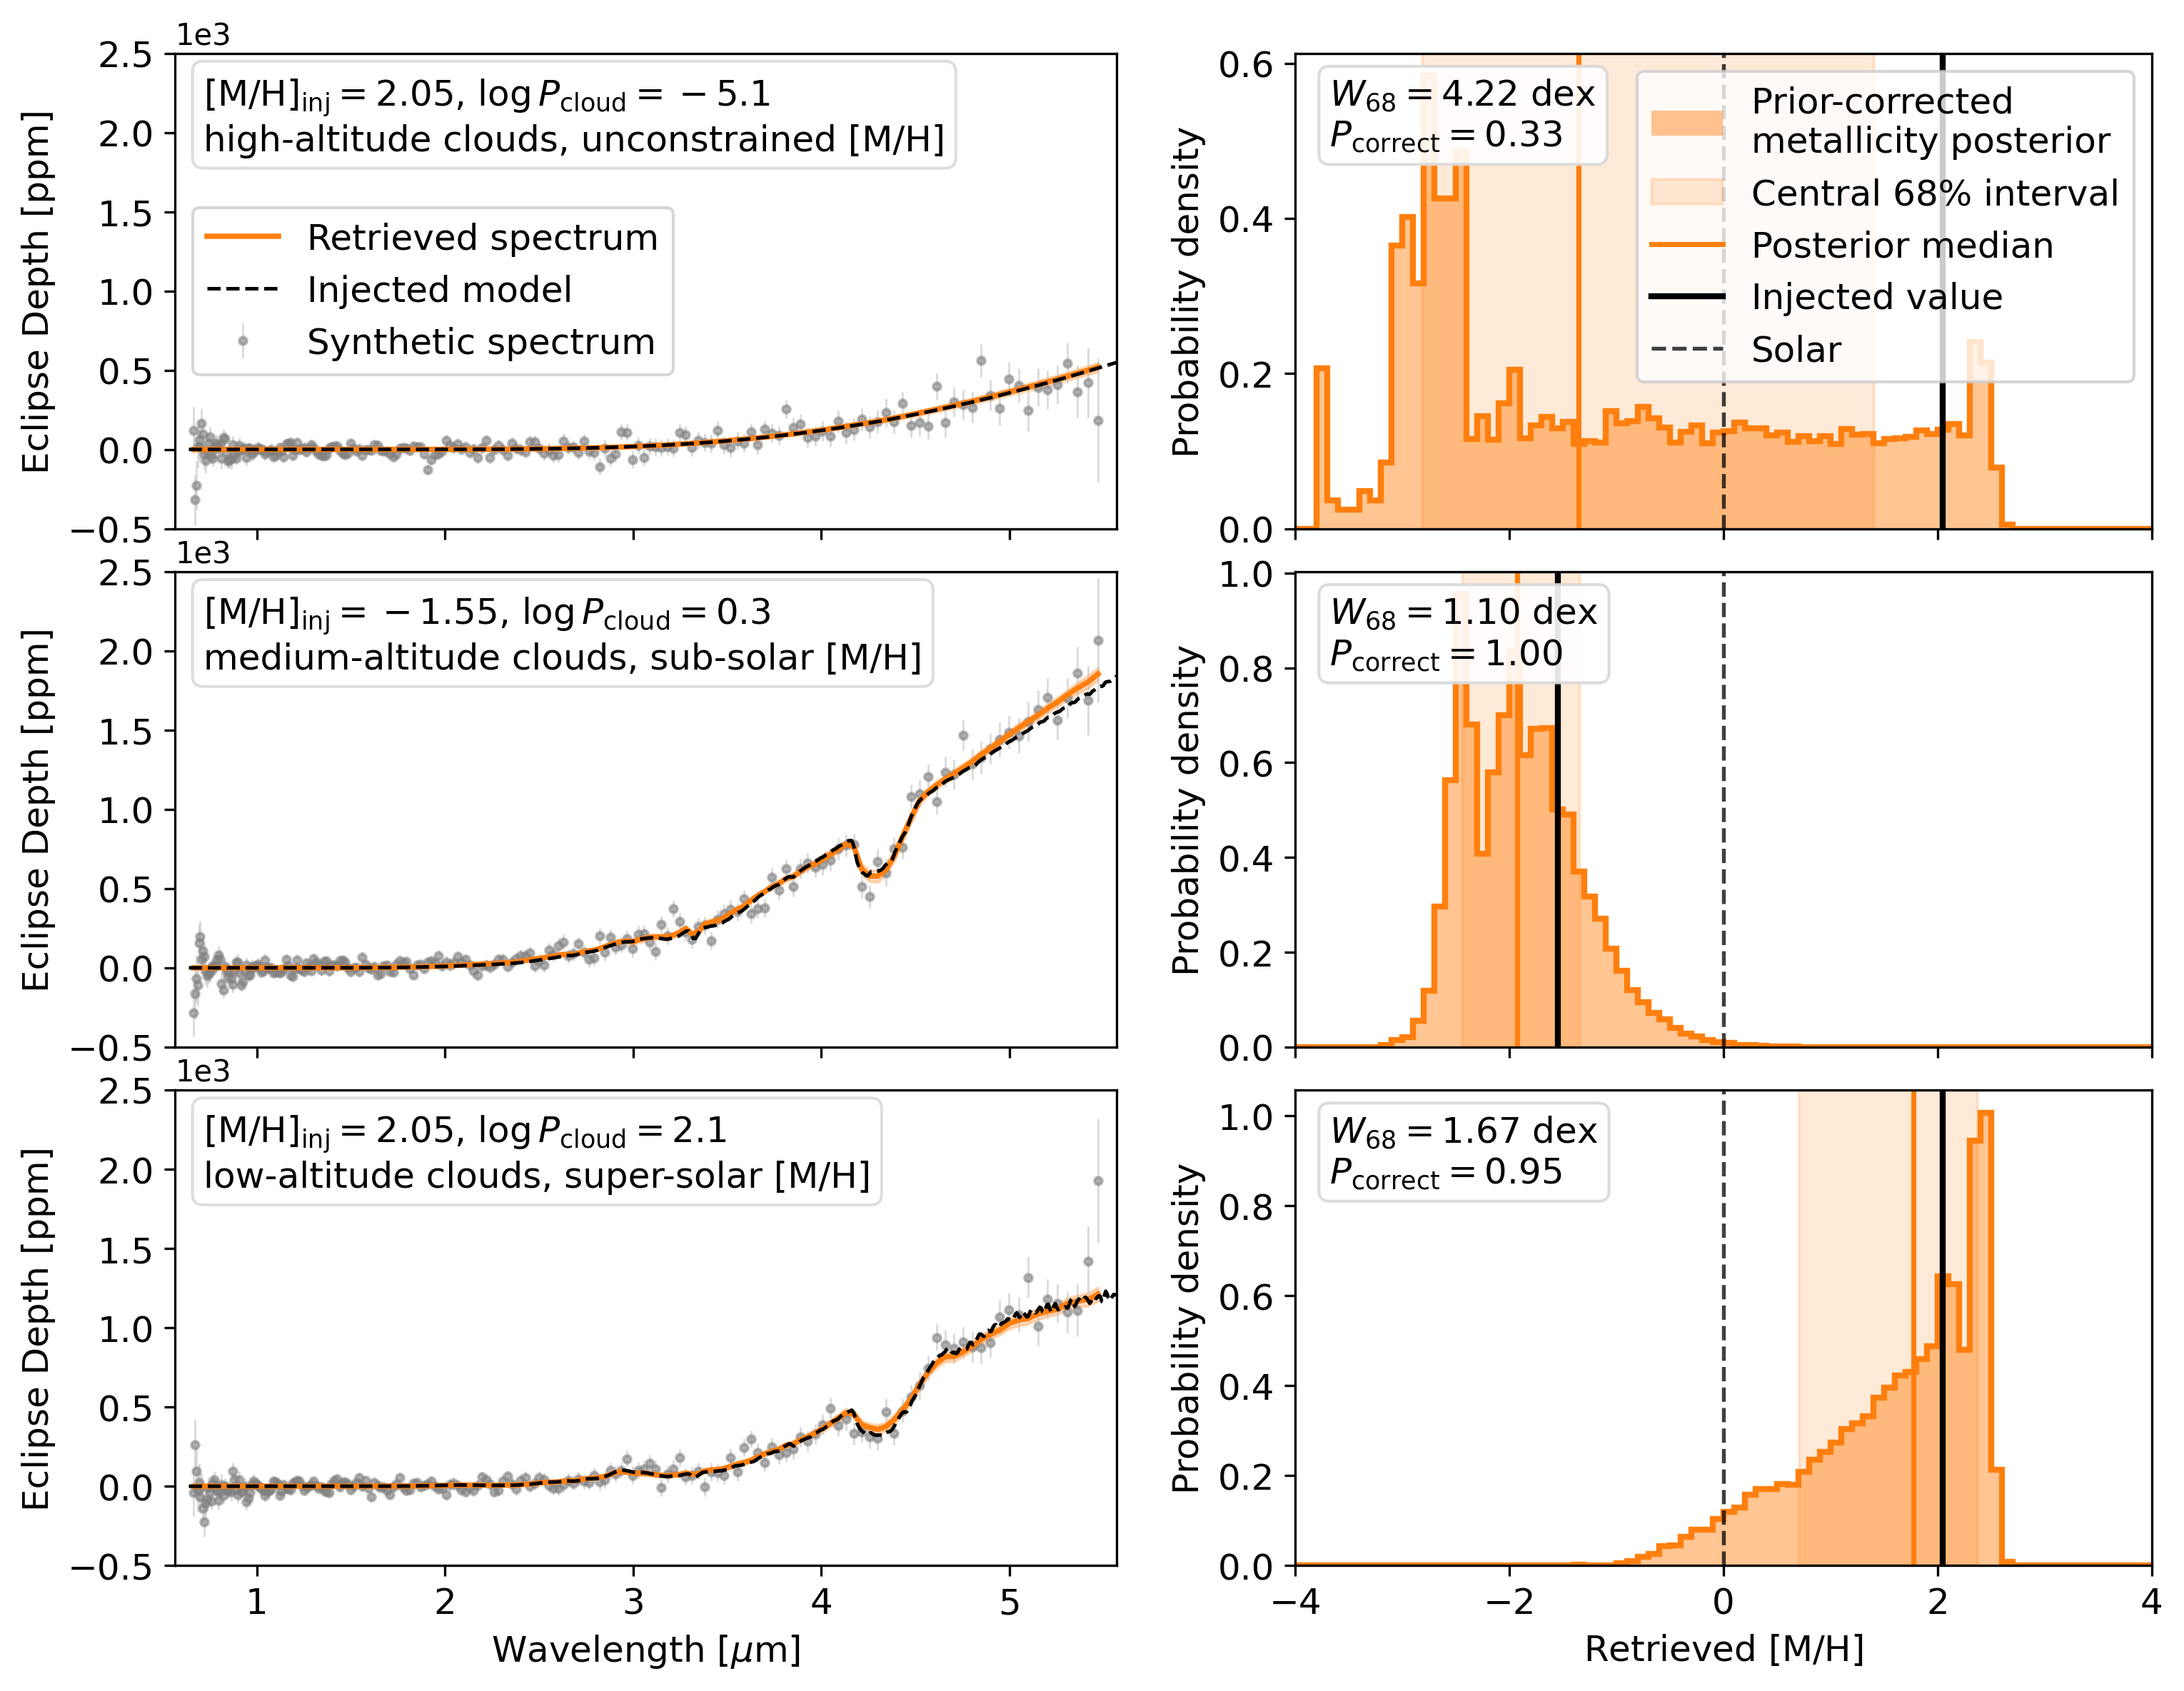

In [29]:
fig_fs = 12

fig, axes = plt.subplots(
    3,
    2,
    figsize=(10, 8),
    dpi=300,
    gridspec_kw={"width_ratios": [1.1, 1.0]},
    sharex="col",
)

bins_met = np.linspace(-4, 4, 81)

for k, (met, logp, subtitle) in enumerate(representative_cases_3):

    d = fig7_data[(met, logp)]

    ax_spec = axes[k, 0]
    ax_met = axes[k, 1]

    # Left panel: spectrum

    ax_spec.errorbar(
        d["wavelengths1"],
        d["depths1"],
        yerr=d["depths_error1"],
        fmt="o",
        ms=2.5,
        lw=0.7,
        color="gray",
        ecolor="0.75",
        alpha=0.55,
        label="Synthetic spectrum",
        zorder=3,
    )

    ax_spec.plot(
        d["wavelengths1"],
        d["median_spec"],
        color="tab:orange",
        lw=1.8,
        label="Retrieved spectrum",
        zorder=4,
    )

    ax_spec.fill_between(
        d["wavelengths1"],
        d["lower_spec"],
        d["upper_spec"],
        color="tab:orange",
        alpha=0.25,
        zorder=1,
    )

    ax_spec.plot(
        d["model_wl"],
        d["model_spectrum"],
        color="black",
        ls="--",
        lw=1.2,
        label="Injected model",
        zorder=5,
    )

    ax_spec.set_ylabel("Eclipse Depth [ppm]", fontsize=fig_fs)
    ax_spec.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax_spec.grid(False)
    ax_spec.set_ylim(-0.5e3, 2.5e3)

    wl_min = np.nanmin(d["wavelengths1"])
    wl_max = np.nanmax(d["wavelengths1"])
    ax_spec.set_xlim(wl_min - 0.1, wl_max + 0.1)

    ax_spec.tick_params(axis="both", which="major", labelsize=fig_fs)

    # Inside title text
    ax_spec.text(
        0.03,
        0.95,
        d["title_left"],
        transform=ax_spec.transAxes,
        ha="left",
        va="top",
        fontsize=fig_fs,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85,
            edgecolor="0.85",
        ),
    )

    # Right panel: prior-corrected metallicity posterior

    ax_met.hist(
        d["retrieved_met"],
        bins=bins_met,
        weights=d["weights"],
        density=True,
        histtype="stepfilled",
        color="tab:orange",
        alpha=0.45,
        label="Prior-corrected \nmetallicity posterior",
    )

    ax_met.hist(
        d["retrieved_met"],
        bins=bins_met,
        weights=d["weights"],
        density=True,
        histtype="step",
        color="tab:orange",
        lw=2.0,
    )

    ax_met.axvspan(
        d["rw_p16"],
        d["rw_p84"],
        color="tab:orange",
        alpha=0.16,
        label=r"Central 68% interval",
    )

    ax_met.axvline(
        d["rw_p50"],
        color="tab:orange",
        lw=1.7,
        label="Posterior median",
    )

    ax_met.axvline(
        d["met_true"],
        color="black",
        lw=2.0,
        label="Injected value",
    )

    ax_met.axvline(
        0,
        color="black",
        lw=1.3,
        ls="--",
        alpha=0.75,
        label="Solar",
    )

    ax_met.set_xlim(-4, 4)
    ax_met.set_ylabel("Probability density", fontsize=fig_fs)
    ax_met.grid(False)

    ax_met.tick_params(axis="both", which="major", labelsize=fig_fs)

    txt = (
        rf"$W_{{68}}={d['rw_width68']:.2f}$ dex"
        + "\n"
        + d["pcorrect_text"]
    )

    ax_met.text(
        0.04,
        0.95,
        txt,
        transform=ax_met.transAxes,
        ha="left",
        va="top",
        fontsize=fig_fs,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.9,
            edgecolor="0.85",
        ),
    )

    if k < 2:
        ax_spec.tick_params(labelbottom=False)
        ax_met.tick_params(labelbottom=False)
        ax_spec.set_xlabel("")
        ax_met.set_xlabel("")
    else:
        ax_spec.set_xlabel(r"Wavelength [$\mu$m]", fontsize=fig_fs)
        ax_met.set_xlabel(r"Retrieved $[\mathrm{M/H}]$", fontsize=fig_fs)

# Legends

handles_spec, labels_spec = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend(
    handles_spec,
    labels_spec,
    loc="best",
    fontsize=fig_fs,
    frameon=True,
)

handles_met, labels_met = axes[0, 1].get_legend_handles_labels()
unique_met = dict(zip(labels_met, handles_met))

axes[0, 1].legend(
    unique_met.values(),
    unique_met.keys(),
    loc="upper right",
    fontsize=fig_fs,
    frameon=True,
)

plt.tight_layout(h_pad=0.0)

plt.show()

## Fig 8

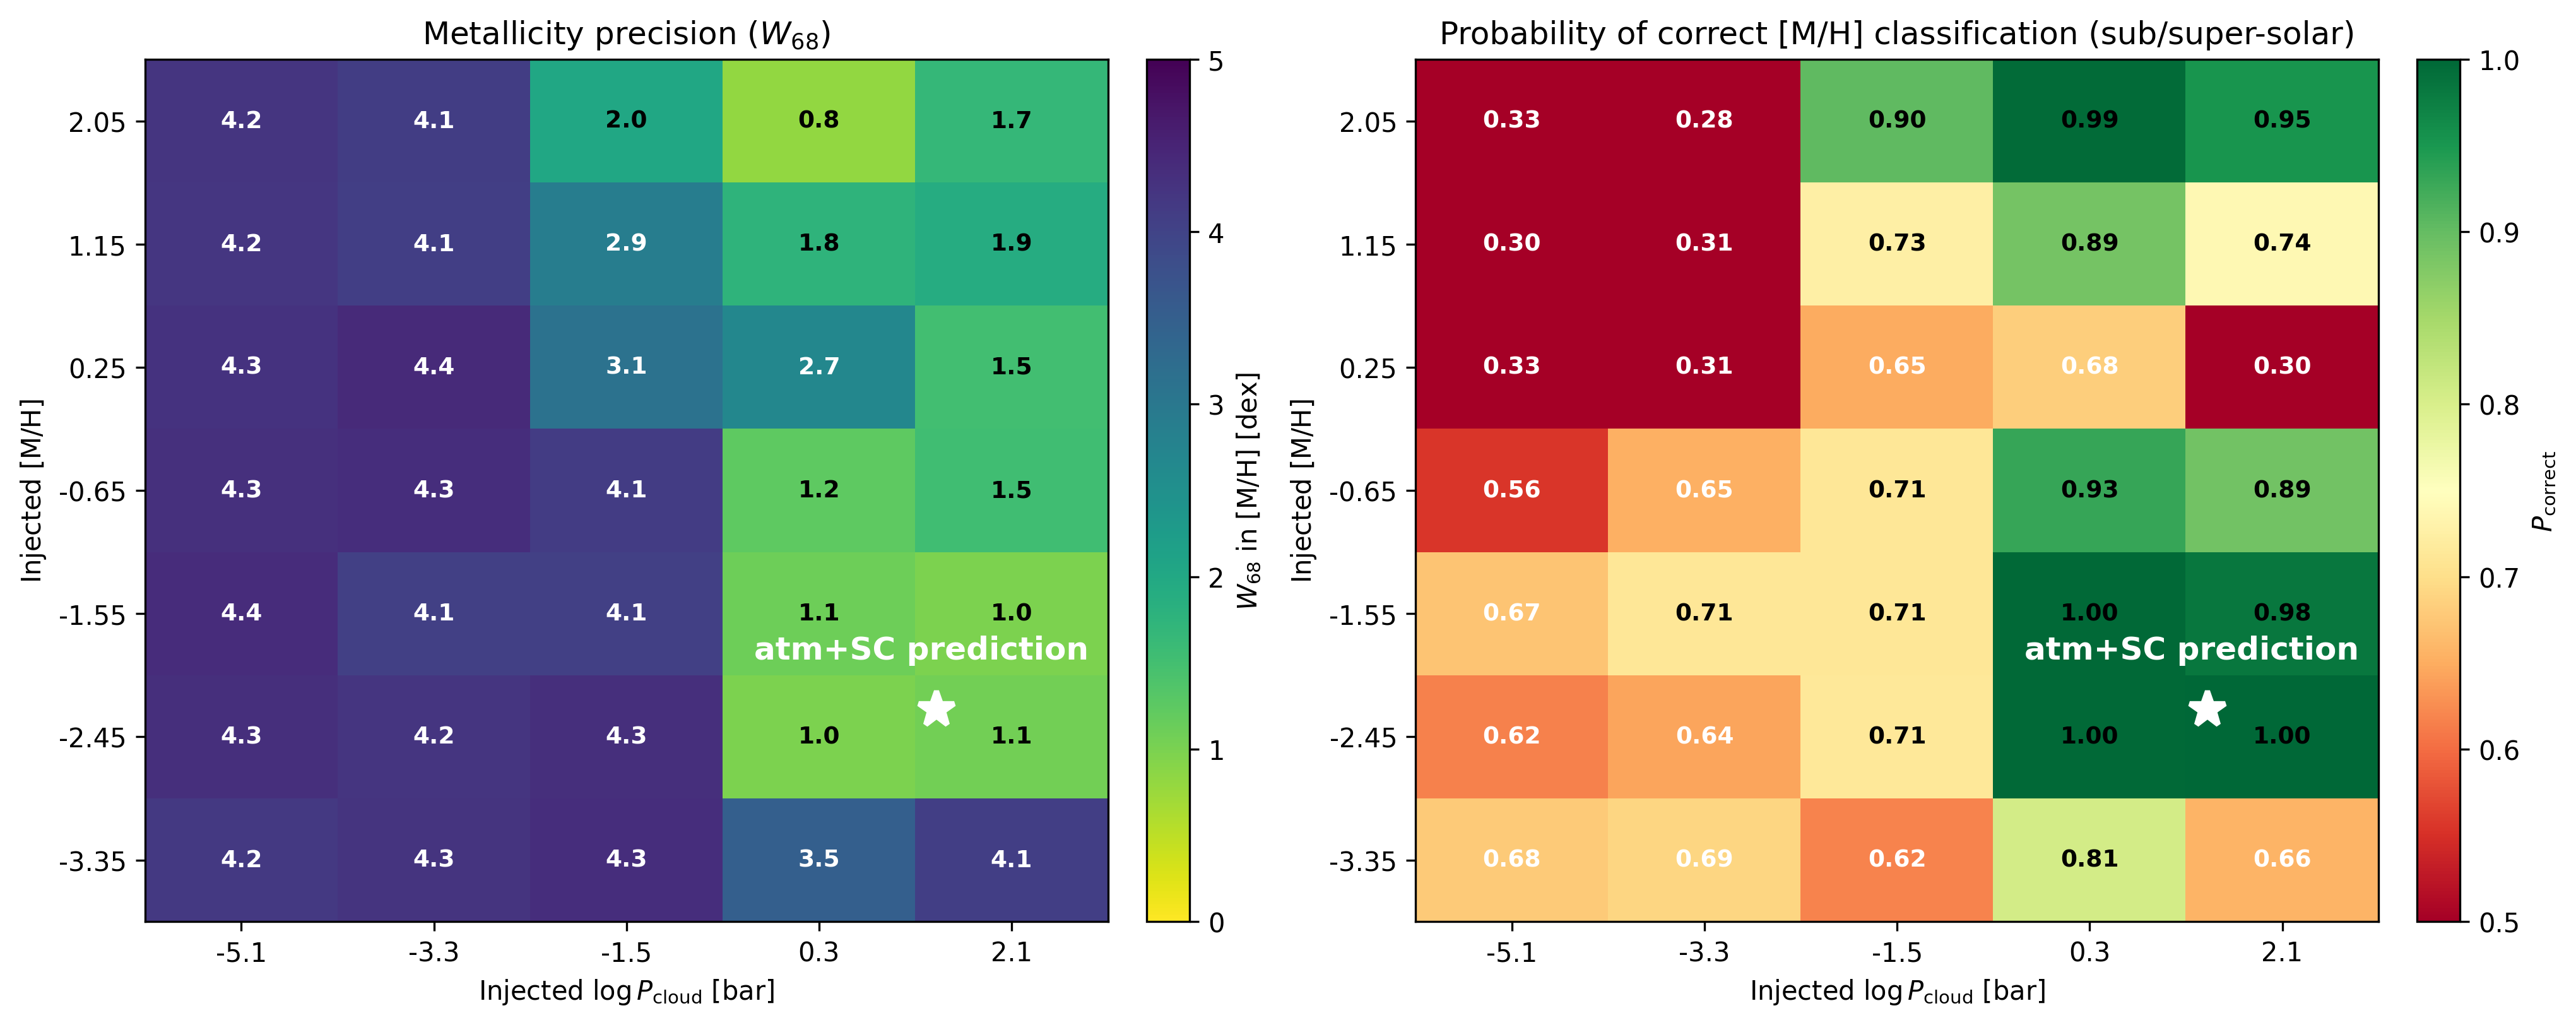

In [30]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.5, 5.3),  # Made taller to accommodate 7 rows instead of 5
    dpi=300,
    constrained_layout=True,
)

ax_w68, ax_pcorrect = axes

# Left heatmap: W68

data = pivot_width.values.astype(float)
masked_data = np.ma.masked_invalid(data)

cmap_w68 = plt.cm.viridis_r.copy()
cmap_w68.set_bad(color="lightgray")

im_w68 = ax_w68.imshow(
    masked_data,
    origin="lower",
    aspect="auto",
    cmap=cmap_w68,
    vmin=0,
    vmax=5,
)

cbar_w68 = fig.colorbar(
    im_w68,
    ax=ax_w68,
    fraction=0.046,
    pad=0.04,
)

cbar_w68.set_label(r"$W_{68}$ in $[\mathrm{M/H}]$ [dex]")

ax_w68.set_title(r"Metallicity precision ($W_{68}$)")
ax_w68.set_xlabel(r"Injected $\log P_{\rm cloud}$ [bar]")
ax_w68.set_ylabel(r"Injected $[\mathrm{M/H}]$")

ax_w68.set_xticks(np.arange(len(logp_grid)))
ax_w68.set_xticklabels([f"{x:.1f}" for x in logp_grid])

ax_w68.set_yticks(np.arange(len(met_grid)))
ax_w68.set_yticklabels([f"{x:.2f}" for x in met_grid])

for i, met in enumerate(met_grid):
    for j, logp in enumerate(logp_grid):

        val = pivot_width.loc[met, logp]

        if np.isfinite(val):
            color = "white" if val > 2.5 else "black"

            ax_w68.text(
                j,
                i,
                f"{val:.1f}",
                ha="center",
                va="center",
                color=color,
                fontsize=9,
                fontweight="bold",
            )
        else:
            ax_w68.text(
                j,
                i,
                "—",
                ha="center",
                va="center",
                color="black",
                fontsize=12,
            )

ax_w68.text(
    2.55,
    len(met_grid) - 0.25,
    r"deeper clouds $\rightarrow$",
    color="white",
    fontsize=8.5,
    ha="left",
    va="top",
)

# Right heatmap: Pcorrect

data = pivot_pcorrect.values.astype(float)
masked_data = np.ma.masked_invalid(data)

cmap_pcorrect = plt.cm.RdYlGn.copy()
cmap_pcorrect.set_bad(color="lightgray")

im_pcorrect = ax_pcorrect.imshow(
    masked_data,
    origin="lower",
    aspect="auto",
    cmap=cmap_pcorrect,
    vmin=0.5,
    vmax=1.0,
)

cbar_pcorrect = fig.colorbar(
    im_pcorrect,
    ax=ax_pcorrect,
    fraction=0.046,
    pad=0.04,
)

cbar_pcorrect.set_label(r"$P_{\rm correct}$")

ax_pcorrect.set_title(r"Probability of correct [M/H] classification (sub/super-solar)")
ax_pcorrect.set_xlabel(r"Injected $\log P_{\rm cloud}$ [bar]")
ax_pcorrect.set_ylabel(r"Injected $[\mathrm{M/H}]$")

ax_pcorrect.set_xticks(np.arange(len(logp_grid)))
ax_pcorrect.set_xticklabels([f"{x:.1f}" for x in logp_grid])

ax_pcorrect.set_yticks(np.arange(len(met_grid)))
ax_pcorrect.set_yticklabels([f"{x:.2f}" for x in met_grid])

for i, met in enumerate(met_grid):
    for j, logp in enumerate(logp_grid):

        val = pivot_pcorrect.loc[met, logp]

        if np.isfinite(val):
            color = "white" if val < 0.7 else "black"

            ax_pcorrect.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                color=color,
                fontsize=9,
                fontweight="bold",
            )
        else:
            ax_pcorrect.text(
                j,
                i,
                "—",
                ha="center",
                va="center",
                color="black",
                fontsize=12,
            )

# Add atm+SC prediction point

atm_sc_met = -2.25
atm_sc_logp = 1.4

x_atm_sc = np.interp(atm_sc_logp, logp_grid, np.arange(len(logp_grid)))

y_atm_sc = np.interp(atm_sc_met, met_grid, np.arange(len(met_grid)))

for ax in [ax_w68, ax_pcorrect]:
    
    ax.set_ylim(-0.5, len(met_grid) - 0.5)

    ax.plot(
        x_atm_sc,
        y_atm_sc,
        marker="*",
        markersize=14,              
        markerfacecolor="white", 
        markeredgecolor="white",      
        markeredgewidth=2.0,
        zorder=10,
        clip_on=False,
    )

    ax.text(
        x_atm_sc - 0.08, 
        y_atm_sc + 0.36,
        "atm+SC prediction", 
        ha="center",  
        va="bottom",
        fontsize=12,
        color="white",
        fontweight="bold",
        zorder=11,
        clip_on=False,
    )

plt.show()